# F070W and HST–JWST CMD Filter Tests

This notebook expands the candidate color--magnitude diagrams to include:

1. NIRCam colors anchored by F070W;
2. HST/WFC3-IR molecular-feature colors;
3. mixed HST and JWST colors;
4. previously tested NIRCam reference projections.

The purpose is to identify diagram spaces that provide a favorable combination of:

- measurable vertical separation with stellar age;
- monotonic ordering in mass or effective temperature;
- limited curvature and self-overlap;
- practical sensitivity to low-mass stars;
- manageable sensitivity to extinction and molecular absorption.

For each group, the notebook generates:

- theoretical isochrone grids spanning 1--20 Myr;
- a common simulated cluster snapshot projected into every diagram.

The same retained primary-star sample is used in every snapshot panel so that changes in morphology reflect the filter projection rather than changes in sample membership.

In [1]:
import os
import sys
import math
import shutil
import warnings
import contextlib
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

from astropy.table import Table, Column

from spisea import synthetic, atmospheres, reddening
from nbody6tools import Reader
from nbody62spisea import converter

sys.path.append('/home/wyz5rge/synthetic-cmd-dev/cmd_generator')
import interpolator

/home/wyz5rge/.venv/nbody/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in /home/wyz5rge/SPISEA/cdbs/extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


particles.bound_subset and particles.bound_indexes will raise ImportError


In [2]:
# ============================================================
# Input paths
# ============================================================

UPDATED_MERGED_ROOT = Path(
    '/home/wyz5rge/SPISEA/evolution/merged/'
    'baraffe_pisa_ekstrom_parsec/'
)

SIM_PATH = (
    '/standard/Tan_JC/backup_protoclusters/multiples/'
    'M3000new/sigma0p1/fiducial/sfe_ff003/00'
)


# ============================================================
# Local isochrone cache
# ============================================================

NOTEBOOK_DIR = Path.cwd()
ISO_CACHE_DIR = NOTEBOOK_DIR / 'isochrone_cache'

# You already deleted the old cache, so this can remain False.
# Set to True only when deliberately regenerating everything.
RESET_ISO_CACHE = False

if RESET_ISO_CACHE and ISO_CACHE_DIR.exists():
    shutil.rmtree(ISO_CACHE_DIR)

ISO_CACHE_DIR.mkdir(parents=True, exist_ok=True)

print('Notebook directory:')
print(NOTEBOOK_DIR)

print('\nIsochrone cache:')
print(ISO_CACHE_DIR)


# ============================================================
# SPISEA settings
# ============================================================

USE_ROTATING_MERGED = False

AKs = 0.0
dist = 410
metallicity = 0.0

atm_func = atmospheres.get_BTSettl_2015_atmosphere
red_law = reddening.RedLawHosek18b()


# ============================================================
# Age grid
# ============================================================

AGE_MIN_MYR = 1.0
AGE_MAX_MYR = 20.0
AGE_STEP_MYR = 0.5

ISO_AGES_MYR = np.arange(
    AGE_MIN_MYR,
    AGE_MAX_MYR + 0.5 * AGE_STEP_MYR,
    AGE_STEP_MYR
)

LOG_AGES = np.log10(ISO_AGES_MYR * 1e6)

print('\nNumber of isochrones:', len(ISO_AGES_MYR))
print(
    f'Age range: {ISO_AGES_MYR.min():.1f}–'
    f'{ISO_AGES_MYR.max():.1f} Myr'
)

Notebook directory:
/sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/07-14_02_model-and-filter-selection

Isochrone cache:
/sfs/gpfs/tardis/home/wyz5rge/synthetic-cmd-dev/notebooks/2026/07-14_02_model-and-filter-selection/isochrone_cache

Number of isochrones: 39
Age range: 1.0–20.0 Myr


In [3]:
# Generate all required photometry in every IsochronePhot call.
ALL_FILTERS = [
    # JWST/NIRCam
    'jwst,F070W',
    'jwst,F115W',
    'jwst,F150W',
    'jwst,F162M',
    'jwst,F182M',
    'jwst,F200W',

    # HST/WFC3-IR
    'wfc3,ir,f125w',
    'wfc3,ir,f139m',
    'wfc3,ir,f160w',
]

# SPISEA output-column names.
FILTER_KEYS = {
    'F070W': 'm_jwst_F070W',
    'F115W': 'm_jwst_F115W',
    'F150W': 'm_jwst_F150W',
    'F162M': 'm_jwst_F162M',
    'F182M': 'm_jwst_F182M',
    'F200W': 'm_jwst_F200W',

    'HST_F125W': 'm_hst_f125w',
    'HST_F139M': 'm_hst_f139m',
    'HST_F160W': 'm_hst_f160w',
}

print('Filters requested from SPISEA:')

for filt in ALL_FILTERS:
    print(' ', filt)

print('\nExpected photometric columns:')

for name, key in FILTER_KEYS.items():
    print(f'  {name:10s} -> {key}')

Filters requested from SPISEA:
  jwst,F070W
  jwst,F115W
  jwst,F150W
  jwst,F162M
  jwst,F182M
  jwst,F200W
  wfc3,ir,f125w
  wfc3,ir,f139m
  wfc3,ir,f160w

Expected photometric columns:
  F070W      -> m_jwst_F070W
  F115W      -> m_jwst_F115W
  F150W      -> m_jwst_F150W
  F162M      -> m_jwst_F162M
  F182M      -> m_jwst_F182M
  F200W      -> m_jwst_F200W
  HST_F125W  -> m_hst_f125w
  HST_F139M  -> m_hst_f139m
  HST_F160W  -> m_hst_f160w


In [4]:
class MergedBaraffePisaEkstromParsecDAT:
    """
    Compatibility reader for the merged
    Baraffe--Pisa--Ekstrom--PARSEC model stored as ASCII .dat files.

    The root directory must contain:
        z015_rot/
        z015_norot/
    """

    def __init__(self, root_dir, rot=False):
        self.root_dir = Path(root_dir).expanduser().resolve()
        self.rot = bool(rot)

        self.model_dir = str(self.root_dir)
        self.z_list = [0.015]
        self.z_solar = 0.015
        self.mass_list = []

        self.grid_dir = self.root_dir / (
            'z015_rot' if self.rot else 'z015_norot'
        )

        if not self.grid_dir.is_dir():
            raise FileNotFoundError(
                f'Merged-model directory not found: {self.grid_dir}'
            )

        paths = sorted(self.grid_dir.glob('iso_*.dat'))

        if len(paths) == 0:
            raise FileNotFoundError(
                f'No iso_*.dat files found in {self.grid_dir}'
            )

        self.age_file_map = {}

        for path in paths:
            try:
                log_age = float(path.stem.split('_')[1])
            except (IndexError, ValueError):
                continue

            self.age_file_map[round(log_age, 2)] = path

        self.age_list = np.array(
            sorted(self.age_file_map.keys()),
            dtype=float
        )

    def isochrone(self, age=1.0e6, metallicity=0.0):
        log_age_requested = math.log10(age)

        if log_age_requested < self.age_list[0]:
            raise ValueError(
                f'Requested logAge={log_age_requested:.4f} is younger '
                f'than grid minimum logAge={self.age_list[0]:.2f}.'
            )

        if log_age_requested > self.age_list[-1]:
            raise ValueError(
                f'Requested logAge={log_age_requested:.4f} is older '
                f'than grid maximum logAge={self.age_list[-1]:.2f}.'
            )

        # Select the nearest native merged-grid age.
        idx = np.argmin(
            np.abs(self.age_list - log_age_requested)
        )

        selected_log_age = float(self.age_list[idx])

        iso_path = self.age_file_map[
            round(selected_log_age, 2)
        ]

        dtype = [
            ('mass', 'f8'),
            ('logT', 'f8'),
            ('logL', 'f8'),
            ('logg', 'f8'),
            ('logT_WR', 'f8'),
            ('mass_current', 'f8'),
            ('phase', 'i4'),
            ('model_ref', 'U32'),
        ]

        data = np.genfromtxt(
            str(iso_path),
            comments='#',
            dtype=dtype,
            encoding='utf-8'
        )

        data = np.atleast_1d(data)
        iso = Table(data)

        is_wr = ~np.isclose(
            np.asarray(iso['logT'], dtype=float),
            np.asarray(iso['logT_WR'], dtype=float),
            rtol=0.0,
            atol=1e-8
        )

        iso.add_column(
            Column(is_wr, name='isWR')
        )

        iso.meta['log_age'] = selected_log_age
        iso.meta['log_age_requested'] = log_age_requested
        iso.meta['metallicity_in'] = metallicity
        iso.meta['metallicity_act'] = 0.0
        iso.meta['source_file'] = str(iso_path)

        return iso

In [5]:
evo_model = MergedBaraffePisaEkstromParsecDAT(
    UPDATED_MERGED_ROOT,
    rot=USE_ROTATING_MERGED
)

test_iso = evo_model.isochrone(
    age=1.0e6,
    metallicity=metallicity
)

print('Model class:')
print(type(evo_model))

print('\nMerged-grid directory:')
print(evo_model.grid_dir)

print('\nTest source:')
print(test_iso.meta['source_file'])

print(
    '\nPhysical mass range at 1 Myr:',
    f"{np.min(test_iso['mass']):.3f}–"
    f"{np.max(test_iso['mass']):.1f} Msun"
)

Model class:
<class '__main__.MergedBaraffePisaEkstromParsecDAT'>

Merged-grid directory:
/sfs/gpfs/tardis/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/z015_norot

Test source:
/sfs/gpfs/tardis/home/wyz5rge/SPISEA/evolution/merged/baraffe_pisa_ekstrom_parsec/z015_norot/iso_6.00.dat

Physical mass range at 1 Myr: 0.010–500.0 Msun


## Group 1: NIRCam F070W-based projections

F070W is the shortest-wavelength NIRCam imaging filter. Pairing it with progressively redder NIRCam filters produces a long color baseline that should be strongly sensitive to effective temperature.

### Potential advantages

- Strong temperature and mass ordering over a long wavelength baseline
- Potentially larger separation between isochrones of different ages
- Useful contrast to the short-baseline F162M/F182M combinations
- Tests whether continuum leverage produces smoother geometry than molecular-band colors
- Red y-axis choices such as F150W or F200W preserve better sensitivity to faint low-mass stars than F070W itself

### Potential disadvantages

- Cool, low-mass stars may be extremely faint in F070W
- Strong sensitivity to extinction and differential reddening
- Long-baseline colors may produce substantial curvature
- Model-atmosphere uncertainties may be more important at the shortest wavelengths
- A visually broad color range does not necessarily imply a reliable vertical age-spread measurement

The comparison between F070W-F200W versus F070W and versus F200W isolates the effect of changing the magnitude axis while retaining the same color.

## Group 2: HST/WFC3-IR projections

The WFC3-IR filters provide an independent instrument and filter system for evaluating CMD geometry.

F125W and F160W are broad filters, while F139M samples a molecular-absorption region in cool-star spectra. These combinations therefore offer both broad-band and molecular-sensitive HST controls.

### Potential advantages

- Tests whether filter-dependent curvature is specific to NIRCam
- F125W-F160W provides a conventional broad near-infrared color
- F125W-F139M tests a molecular-feature strategy analogous to the NIRCam medium-filter combinations
- Useful for connecting the synthetic framework to existing archival HST observations

### Potential disadvantages

- The wavelength baselines are generally shorter than F070W-to-F200W
- HST/WFC3-IR spatial resolution and depth differ from NIRCam
- F139M may reproduce the same molecularly induced hooks that complicate F182M-based CMDs
- Narrower or medium filters may have lower signal-to-noise for the faintest sources

## Group 3: Combined HST and JWST projections

Cross-instrument colors combine HST/WFC3-IR measurements with JWST/NIRCam magnitudes.

These combinations test whether a color spanning two different filter systems offers improved temperature leverage or age separation.

### Potential advantages

- Extends the available color baseline beyond nearby filters within a single instrument
- Allows direct use of legacy HST imaging together with new JWST observations
- Tests whether an HST continuum or molecular-sensitive measurement can complement a JWST y-axis
- Red JWST magnitude axes retain favorable sensitivity to cool, low-mass sources

### Potential disadvantages

- Cross-instrument catalogs require careful astrometric matching
- Different angular resolutions may create blending and multiplicity biases
- Completeness and photometric uncertainties will differ between instruments
- Zeropoint and calibration systematics can enter the color
- Similar effective wavelengths may produce little leverage despite using two instruments

These projections are primarily exploratory and should be retained for the final analysis only if their isochrone geometry is clearly superior.

In [6]:
# Tuple format:
# (
#     first shorthand filter,
#     second shorthand filter,
#     y-axis shorthand filter,
#     title
# )

F070W_GROUP = [
    (
        'F070W', 'F115W', 'F115W',
        'F070W-F115W vs F115W'
    ),
    (
        'F070W', 'F150W', 'F150W',
        'F070W-F150W vs F150W'
    ),
    (
        'F070W', 'F200W', 'F200W',
        'F070W-F200W vs F200W'
    ),
    (
        'F070W', 'F200W', 'F070W',
        'F070W-F200W vs F070W'
    ),
]

HST_GROUP = [
    (
        'HST_F125W', 'HST_F139M', 'HST_F139M',
        'HST F125W-F139M vs F139M'
    ),
    (
        'HST_F125W', 'HST_F160W', 'HST_F160W',
        'HST F125W-F160W vs F160W'
    ),
    (
        'HST_F139M', 'HST_F160W', 'HST_F160W',
        'HST F139M-F160W vs F160W'
    ),
    (
        'HST_F125W', 'HST_F160W', 'HST_F125W',
        'HST F125W-F160W vs F125W'
    ),
]

CROSS_INSTRUMENT_GROUP = [
    (
        'HST_F125W', 'F182M', 'F182M',
        'HST F125W-JWST F182M vs F182M'
    ),
    (
        'HST_F139M', 'F182M', 'F182M',
        'HST F139M-JWST F182M vs F182M'
    ),
    (
        'HST_F160W', 'F182M', 'F182M',
        'HST F160W-JWST F182M vs F182M'
    ),
    (
        'HST_F160W', 'F200W', 'F200W',
        'HST F160W-JWST F200W vs F200W'
    ),
]

CMD_GROUPS = {
    'NIRCam F070W-based projections': F070W_GROUP,
    'HST/WFC3-IR projections': HST_GROUP,
    'Combined HST and JWST projections': CROSS_INSTRUMENT_GROUP,
}

for group_name, choices in CMD_GROUPS.items():
    print('\n' + group_name)

    for choice in choices:
        print(' ', choice[3])


NIRCam F070W-based projections
  F070W-F115W vs F115W
  F070W-F150W vs F150W
  F070W-F200W vs F200W
  F070W-F200W vs F070W

HST/WFC3-IR projections
  HST F125W-F139M vs F139M
  HST F125W-F160W vs F160W
  HST F139M-F160W vs F160W
  HST F125W-F160W vs F125W

Combined HST and JWST projections
  HST F125W-JWST F182M vs F182M
  HST F139M-JWST F182M vs F182M
  HST F160W-JWST F182M vs F182M
  HST F160W-JWST F200W vs F200W


In [7]:
def build_multifilter_isochrone_grid():
    iso_grid = []
    records = []

    for age_myr, log_age in zip(ISO_AGES_MYR, LOG_AGES):
        print(f'Building age = {age_myr:4.1f} Myr')

        try:
            iso = synthetic.IsochronePhot(
                log_age,
                AKs,
                dist,
                metallicity=metallicity,
                evo_model=evo_model,
                atm_func=atm_func,
                red_law=red_law,
                filters=ALL_FILTERS,
                iso_dir=str(ISO_CACHE_DIR)
            )

            missing = [
                key for key in FILTER_KEYS.values()
                if key not in iso.points.colnames
            ]

            if missing:
                raise KeyError(
                    'Photometric isochrone is missing columns: '
                    f'{missing}\n'
                    'Delete isochrone_cache or set '
                    'RESET_ISO_CACHE=True before rerunning.'
                )

            mass = np.asarray(
                iso.points['mass'],
                dtype=float
            )

            iso_grid.append(iso)

            records.append({
                'age_myr': age_myr,
                'log_age': log_age,
                'n_points': len(iso.points),
                'mass_min': np.nanmin(mass),
                'mass_max': np.nanmax(mass),
                'status': 'success',
                'error': '',
            })

        except Exception as exc:
            print(f'FAILED at {age_myr:.1f} Myr: {exc}')

            iso_grid.append(None)

            records.append({
                'age_myr': age_myr,
                'log_age': log_age,
                'n_points': 0,
                'mass_min': np.nan,
                'mass_max': np.nan,
                'status': 'failed',
                'error': str(exc),
            })

    return iso_grid, pd.DataFrame(records)


ISO_GRID, df_iso_coverage = build_multifilter_isochrone_grid()

display(df_iso_coverage)

Building age =  1.0 Myr


Building age =  1.5 Myr
Building age =  2.0 Myr
Building age =  2.5 Myr
Building age =  3.0 Myr
Building age =  3.5 Myr
Building age =  4.0 Myr
Building age =  4.5 Myr


Building age =  5.0 Myr


Building age =  5.5 Myr


Building age =  6.0 Myr


...

Building age = 16.5 Myr
Building age = 17.0 Myr


Building age = 17.5 Myr
Building age = 18.0 Myr


Building age = 18.5 Myr


Building age = 19.0 Myr
Building age = 19.5 Myr
Building age = 20.0 Myr


,age_myr,log_age,n_points,mass_min,mass_max,status,error
0,1.0,6.000000,1178,0.01,500.000,success,
1,1.5,6.176091,1287,0.01,500.000,success,
2,2.0,6.301030,1330,0.01,500.000,success,
3,2.5,6.397940,2333,0.01,259.154,success,
4,3.0,6.477121,1856,0.01,116.520,success,
5,3.5,6.544068,1884,0.01,80.336,success,
6,4.0,6.602060,1704,0.01,58.761,success,
7,4.5,6.653213,1571,0.01,47.174,success,
8,5.0,6.698970,1529,0.01,39.109,success,
9,5.5,6.740363,1525,0.01,34.304,success,


In [8]:
first_valid_iso = next(
    iso for iso in ISO_GRID
    if iso is not None
)

print('Columns in first valid photometric isochrone:')

for colname in first_valid_iso.points.colnames:
    print(' ', colname)

print('\nRequired-filter validation:')

for short_name, key in FILTER_KEYS.items():
    status = key in first_valid_iso.points.colnames
    print(f'  {short_name:10s} {key:20s} {status}')

Columns in first valid photometric isochrone:
  L
  Teff
  R
  mass
  logg
  isWR
  mass_current
  phase
  m_jwst_F070W
  m_jwst_F115W
  m_jwst_F150W
  m_jwst_F162M
  m_jwst_F182M
  m_jwst_F200W
  m_hst_f125w
  m_hst_f139m
  m_hst_f160w

Required-filter validation:
  F070W      m_jwst_F070W         True
  F115W      m_jwst_F115W         True
  F150W      m_jwst_F150W         True
  F162M      m_jwst_F162M         True
  F182M      m_jwst_F182M         True
  F200W      m_jwst_F200W         True
  HST_F125W  m_hst_f125w          True
  HST_F139M  m_hst_f139m          True
  HST_F160W  m_hst_f160w          True


In [9]:
L_SUN_WATTS = 3.846e26


def get_hr_coordinates(iso):
    if iso is None:
        return np.array([]), np.array([]), np.array([])

    pts = iso.points

    teff = np.asarray(pts['Teff'], dtype=float)
    luminosity_watts = np.asarray(pts['L'], dtype=float)
    mass = np.asarray(pts['mass'], dtype=float)

    log_luminosity = np.log10(
        luminosity_watts / L_SUN_WATTS
    )

    good = (
        np.isfinite(teff) &
        np.isfinite(log_luminosity) &
        np.isfinite(mass)
    )

    return (
        teff[good],
        log_luminosity[good],
        mass[good]
    )


def get_cmd_coordinates(iso, cmd_choice):
    if iso is None:
        return np.array([]), np.array([]), np.array([])

    filt_a, filt_b, y_filter, _ = cmd_choice

    pts = iso.points

    key_a = FILTER_KEYS[filt_a]
    key_b = FILTER_KEYS[filt_b]
    key_y = FILTER_KEYS[y_filter]

    mag_a = np.asarray(pts[key_a], dtype=float)
    mag_b = np.asarray(pts[key_b], dtype=float)
    ymag = np.asarray(pts[key_y], dtype=float)
    mass = np.asarray(pts['mass'], dtype=float)

    color = mag_a - mag_b

    good = (
        np.isfinite(color) &
        np.isfinite(ymag) &
        np.isfinite(mass)
    )

    return (
        color[good],
        ymag[good],
        mass[good]
    )

In [10]:
def plot_theoretical_group(
    group_name,
    cmd_choices,
    include_hr=True
):
    n_panels = len(cmd_choices) + int(include_hr)

    ncols = 3
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 5.0 * nrows),
        squeeze=False
    )

    axes = axes.flatten()

    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(
        vmin=ISO_AGES_MYR.min(),
        vmax=ISO_AGES_MYR.max()
    )

    panel_index = 0

    if include_hr:
        ax = axes[panel_index]

        for iso, age_myr in zip(
            ISO_GRID,
            ISO_AGES_MYR
        ):
            x, y, _ = get_hr_coordinates(iso)

            if len(x) == 0:
                continue

            ax.plot(
                x,
                y,
                color=cmap(norm(age_myr)),
                lw=1.0,
                alpha=0.68
            )

        ax.set_title(r'Luminosity vs $T_{\rm eff}$')
        ax.set_xlabel(r'$T_{\rm eff}$ (K)')
        ax.set_ylabel(r'$\log_{10}(L/L_\odot)$')
        ax.invert_xaxis()
        ax.grid(alpha=0.22)

        panel_index += 1

    for cmd_choice in cmd_choices:
        ax = axes[panel_index]

        filt_a, filt_b, y_filter, title = cmd_choice

        for iso, age_myr in zip(
            ISO_GRID,
            ISO_AGES_MYR
        ):
            x, y, _ = get_cmd_coordinates(
                iso,
                cmd_choice
            )

            if len(x) == 0:
                continue

            ax.plot(
                x,
                y,
                color=cmap(norm(age_myr)),
                lw=1.0,
                alpha=0.68
            )

        ax.set_title(title)
        ax.set_xlabel(f'{filt_a} - {filt_b}')
        ax.set_ylabel(y_filter)
        ax.invert_yaxis()
        ax.grid(alpha=0.22)

        panel_index += 1

    for ax in axes[panel_index:]:
        ax.axis('off')

    sm = ScalarMappable(
        norm=norm,
        cmap=cmap
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes[:panel_index].tolist(),
        pad=0.015,
        fraction=0.025
    )
    cbar.set_label('Isochrone age (Myr)')

    fig.suptitle(
        f'{group_name}\n'
        'Merged-model theoretical isochrones, 1–20 Myr',
        fontsize=16
    )

    plt.subplots_adjust(
        top=0.90,
        right=0.91,
        wspace=0.28,
        hspace=0.31
    )

    plt.show()

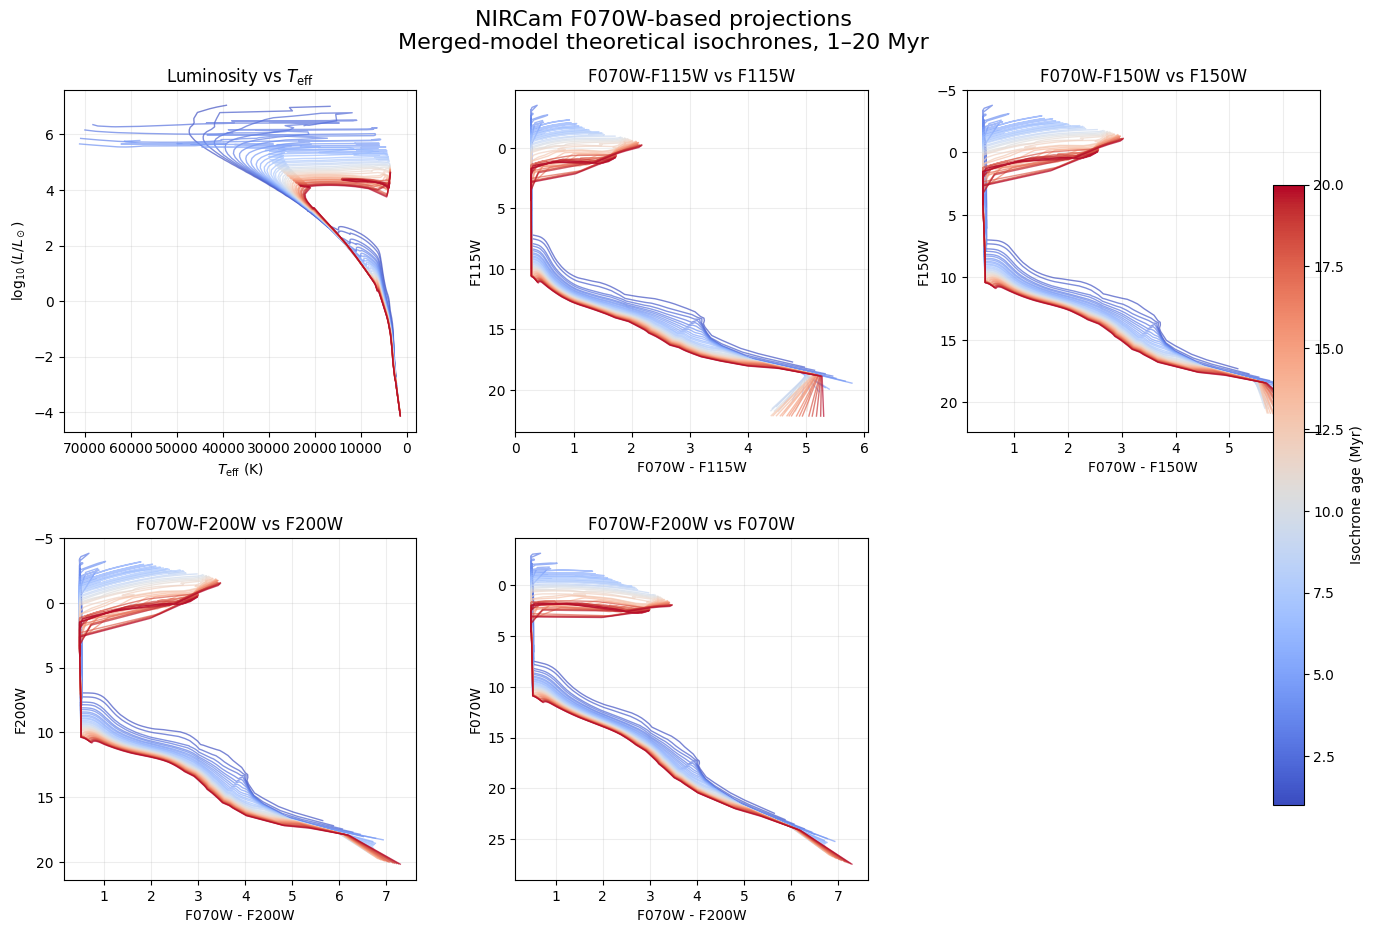

In [11]:
plot_theoretical_group(
    'NIRCam F070W-based projections',
    F070W_GROUP,
    include_hr=True
)

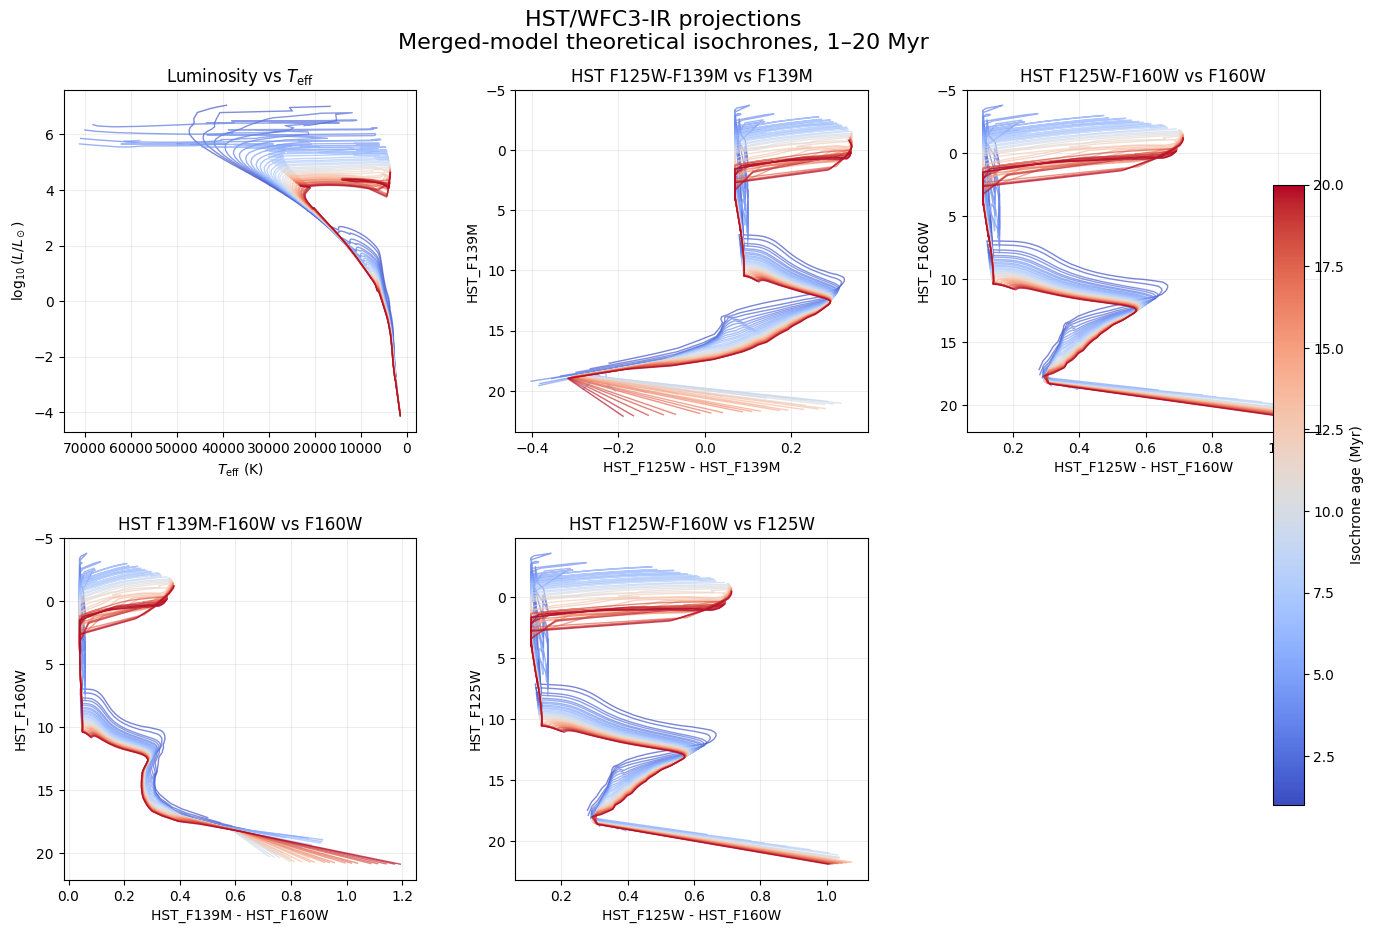

In [12]:
plot_theoretical_group(
    'HST/WFC3-IR projections',
    HST_GROUP,
    include_hr=True
)

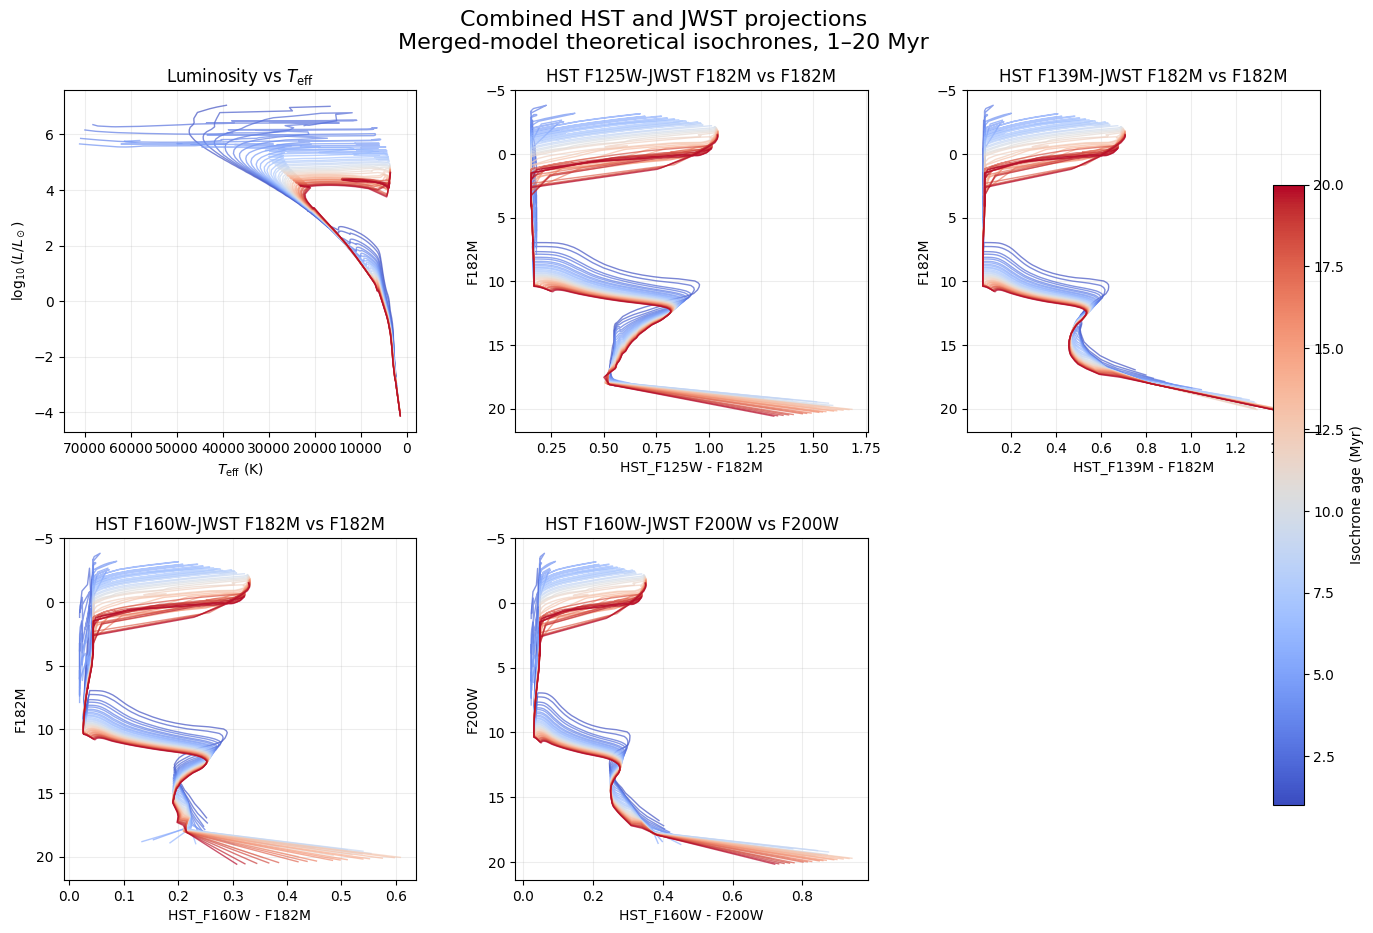

In [13]:
plot_theoretical_group(
    'Combined HST and JWST projections',
    CROSS_INSTRUMENT_GROUP,
    include_hr=True
)

# Common Simulation Snapshot

The same cluster snapshot is now projected into each candidate CMD.

The initial comparison uses primary stars only. A star is retained only if:

1. its age is within the 1--20 Myr isochrone grid;
2. its mass is supported by the bracketing isochrones;
3. interpolation succeeds in every required filter.

Using one common retained catalog prevents differences in panel morphology from being caused by different stars being rejected for different filter choices.

Unresolved binaries can be incorporated after the preferred filter combinations have been identified.

In [14]:
SNAPSHOT_TIME_MYR = 5.0


def load_cluster_table(sim_path, snapshot_time_myr):
    sim_path = os.path.abspath(sim_path)

    if not sim_path.endswith('/'):
        sim_path += '/'

    print('Reading snapshot from:')
    print(sim_path)

    snapshot = Reader.read_snapshot(
        sim_path,
        time=snapshot_time_myr
    )

    snapshot.to_physical()

    return converter.to_spicea_table(snapshot)


cluster_table = load_cluster_table(
    SIM_PATH,
    SNAPSHOT_TIME_MYR
)

print('\nSystems in snapshot:', len(cluster_table))

snapshot_ages = np.asarray(
    cluster_table['age'],
    dtype=float
)

snapshot_masses = np.asarray(
    cluster_table['mass'],
    dtype=float
)

print(
    'Stellar age range:',
    f'{np.nanmin(snapshot_ages):.3f}–'
    f'{np.nanmax(snapshot_ages):.3f} Myr'
)

print(
    'Primary-mass range:',
    f'{np.nanmin(snapshot_masses):.3f}–'
    f'{np.nanmax(snapshot_masses):.3f} Msun'
)

Reading snapshot from:
/standard/Tan_JC/backup_protoclusters/multiples/M3000new/sigma0p1/fiducial/sfe_ff003/00/



Systems in snapshot: 2329
Stellar age range: -1.278–4.973 Myr
Primary-mass range: 0.010–25.388 Msun


In [15]:
def safe_interpolate(
    age_myr,
    mass,
    iso_grid,
    log_age_arr,
    filter_pair
):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')

            with contextlib.redirect_stdout(io.StringIO()):
                with contextlib.redirect_stderr(io.StringIO()):
                    result = interpolator.interpolate(
                        age_myr,
                        mass,
                        iso_grid,
                        log_age_arr,
                        filter_pair
                    )

        if result is None:
            return None

        result = np.asarray(result, dtype=float)

        if not np.all(np.isfinite(result)):
            return None

        return result

    except Exception:
        return None

In [16]:
INTERPOLATION_PAIRS = [
    ('F070W', 'F115W'),
    ('F150W', 'F162M'),
    ('F182M', 'F200W'),
    ('HST_F125W', 'HST_F139M'),
    ('HST_F139M', 'HST_F160W'),
]

print('Interpolation pairs:')

for filt_a, filt_b in INTERPOLATION_PAIRS:
    print(f'  {filt_a} + {filt_b}')

Interpolation pairs:
  F070W + F115W
  F150W + F162M
  F182M + F200W
  HST_F125W + HST_F139M
  HST_F139M + HST_F160W


In [17]:
def build_common_snapshot_catalog(
    cluster_table,
    iso_grid,
    log_age_arr
):
    masses = np.asarray(
        cluster_table['mass'],
        dtype=float
    )

    ages_myr = np.asarray(
        cluster_table['age'],
        dtype=float
    )

    grid_ages_myr = (
        np.power(
            10.0,
            np.asarray(log_age_arr, dtype=float)
        ) / 1e6
    )

    rows = []

    rejection_counts = {
        'age_below_grid': 0,
        'age_above_grid': 0,
        'interpolation_failure': 0,
        'retained': 0,
    }

    for system_index, (mass, age_myr) in enumerate(
        zip(masses, ages_myr)
    ):
        if age_myr < grid_ages_myr[0]:
            rejection_counts['age_below_grid'] += 1
            continue

        if age_myr > grid_ages_myr[-1]:
            rejection_counts['age_above_grid'] += 1
            continue

        row = {
            'system_index': system_index,
            'mass': mass,
            'age_myr': age_myr,
        }

        successful = True
        physical_values_stored = False

        for filt_a, filt_b in INTERPOLATION_PAIRS:
            key_a = FILTER_KEYS[filt_a]
            key_b = FILTER_KEYS[filt_b]

            star = safe_interpolate(
                age_myr,
                mass,
                iso_grid,
                log_age_arr,
                [key_a, key_b]
            )

            if star is None:
                successful = False
                break

            # Existing interpolator output:
            # [luminosity, Teff, logg, mag_a, mag_b]
            luminosity_watts = float(star[0])
            teff = float(star[1])
            logg = float(star[2])
            mag_a = float(star[3])
            mag_b = float(star[4])

            if not physical_values_stored:
                row['luminosity_watts'] = luminosity_watts
                row['log_luminosity_lsun'] = np.log10(
                    luminosity_watts / L_SUN_WATTS
                )
                row['teff'] = teff
                row['logg'] = logg

                physical_values_stored = True

            row[f'mag_{filt_a}'] = mag_a
            row[f'mag_{filt_b}'] = mag_b

        if not successful:
            rejection_counts['interpolation_failure'] += 1
            continue

        rows.append(row)
        rejection_counts['retained'] += 1

    return pd.DataFrame(rows), rejection_counts


df_snapshot, snapshot_rejections = (
    build_common_snapshot_catalog(
        cluster_table,
        ISO_GRID,
        LOG_AGES
    )
)

print('Snapshot retention:')

for reason, count in snapshot_rejections.items():
    print(f'  {reason}: {count}')

print('\nCommon retained sample:', len(df_snapshot))

display(df_snapshot.head())

Snapshot retention:
  age_below_grid: 397
  age_above_grid: 0
  interpolation_failure: 21
  retained: 1911

Common retained sample: 1911


,system_index,mass,age_myr,luminosity_watts,log_luminosity_lsun,teff,logg,mag_F070W,mag_F115W,mag_F150W,mag_F162M,mag_F182M,mag_F200W,mag_HST_F125W,mag_HST_F139M,mag_HST_F160W
0,0,0.071258,4.386639,8.016446e+24,-1.681027,2922.775,3.787,18.307,15.213,14.726,14.379,14.459,14.391,15.023,14.953,14.655
1,1,0.418694,4.972991,5.991171e+25,-0.807498,3576.744,4.035,15.185,13.272,12.582,12.305,12.253,12.223,13.068,12.803,12.504
2,2,0.375262,2.503665,8.391677e+25,-0.661161,3549.563,3.829,14.886,12.907,12.191,11.900,11.852,11.824,12.697,12.425,12.110
3,3,0.046876,2.505444,6.344373e+24,-1.782621,2815.757,3.647,18.758,15.456,14.993,14.631,14.714,14.636,15.265,15.229,14.921
4,4,0.033490,2.505444,3.343409e+24,-2.060820,2733.182,3.734,19.646,16.166,15.714,15.338,15.425,15.337,15.973,15.963,15.640


In [18]:
required_magnitude_columns = [
    f'mag_{short_name}'
    for short_name in FILTER_KEYS
]

missing_columns = [
    column
    for column in required_magnitude_columns
    if column not in df_snapshot.columns
]

if missing_columns:
    raise KeyError(
        'The snapshot catalog is missing the following columns:\n'
        + '\n'.join(missing_columns)
    )

print('All required magnitudes are present.')

print('\nNaN counts:')

display(
    df_snapshot[
        required_magnitude_columns
    ].isna().sum()
)

All required magnitudes are present.

NaN counts:


mag_F070W        0
mag_F115W        0
mag_F150W        0
mag_F162M        0
mag_F182M        0
mag_F200W        0
mag_HST_F125W    0
mag_HST_F139M    0
mag_HST_F160W    0
dtype: int64

In [19]:
def plot_snapshot_group(
    group_name,
    cmd_choices,
    include_hr=True
):
    n_panels = len(cmd_choices) + int(include_hr)

    ncols = 3
    nrows = math.ceil(n_panels / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 5.0 * nrows),
        squeeze=False
    )

    axes = axes.flatten()

    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(
        vmin=ISO_AGES_MYR.min(),
        vmax=ISO_AGES_MYR.max()
    )

    panel_index = 0

    if include_hr:
        ax = axes[panel_index]

        for iso, age_myr in zip(
            ISO_GRID,
            ISO_AGES_MYR
        ):
            x_iso, y_iso, _ = get_hr_coordinates(iso)

            if len(x_iso) == 0:
                continue

            ax.plot(
                x_iso,
                y_iso,
                color=cmap(norm(age_myr)),
                lw=0.8,
                alpha=0.25,
                zorder=1
            )

        ax.scatter(
            df_snapshot['teff'],
            df_snapshot['log_luminosity_lsun'],
            s=7,
            color='black',
            alpha=0.50,
            edgecolors='none',
            zorder=3
        )

        ax.set_title(r'Luminosity vs $T_{\rm eff}$')
        ax.set_xlabel(r'$T_{\rm eff}$ (K)')
        ax.set_ylabel(r'$\log_{10}(L/L_\odot)$')
        ax.invert_xaxis()
        ax.grid(alpha=0.22)

        panel_index += 1

    for cmd_choice in cmd_choices:
        ax = axes[panel_index]

        filt_a, filt_b, y_filter, title = cmd_choice

        for iso, age_myr in zip(
            ISO_GRID,
            ISO_AGES_MYR
        ):
            x_iso, y_iso, _ = get_cmd_coordinates(
                iso,
                cmd_choice
            )

            if len(x_iso) == 0:
                continue

            ax.plot(
                x_iso,
                y_iso,
                color=cmap(norm(age_myr)),
                lw=0.8,
                alpha=0.25,
                zorder=1
            )

        color = (
            df_snapshot[f'mag_{filt_a}']
            - df_snapshot[f'mag_{filt_b}']
        )

        ymag = df_snapshot[f'mag_{y_filter}']

        ax.scatter(
            color,
            ymag,
            s=7,
            color='black',
            alpha=0.50,
            edgecolors='none',
            zorder=3
        )

        ax.set_title(title)
        ax.set_xlabel(f'{filt_a} - {filt_b}')
        ax.set_ylabel(y_filter)
        ax.invert_yaxis()
        ax.grid(alpha=0.22)

        panel_index += 1

    for ax in axes[panel_index:]:
        ax.axis('off')

    for ax in axes[:panel_index]:
        ax.text(
            0.03,
            0.97,
            f'N = {len(df_snapshot)}',
            transform=ax.transAxes,
            ha='left',
            va='top',
            fontsize=9,
            bbox=dict(
                boxstyle='round',
                facecolor='white',
                alpha=0.82
            )
        )

    sm = ScalarMappable(
        norm=norm,
        cmap=cmap
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes[:panel_index].tolist(),
        pad=0.015,
        fraction=0.025
    )

    cbar.set_label('Isochrone age (Myr)')

    fig.suptitle(
        f'{group_name}\n'
        rf'Common cluster snapshot: '
        rf'$\Sigma_{{\rm cloud}}=0.1$ g cm$^{{-2}}$, '
        rf'$\epsilon_{{\rm ff}}=0.03$, '
        f't={SNAPSHOT_TIME_MYR:.2f} Myr',
        fontsize=16
    )

    plt.subplots_adjust(
        top=0.89,
        right=0.91,
        wspace=0.28,
        hspace=0.31
    )

    plt.show()

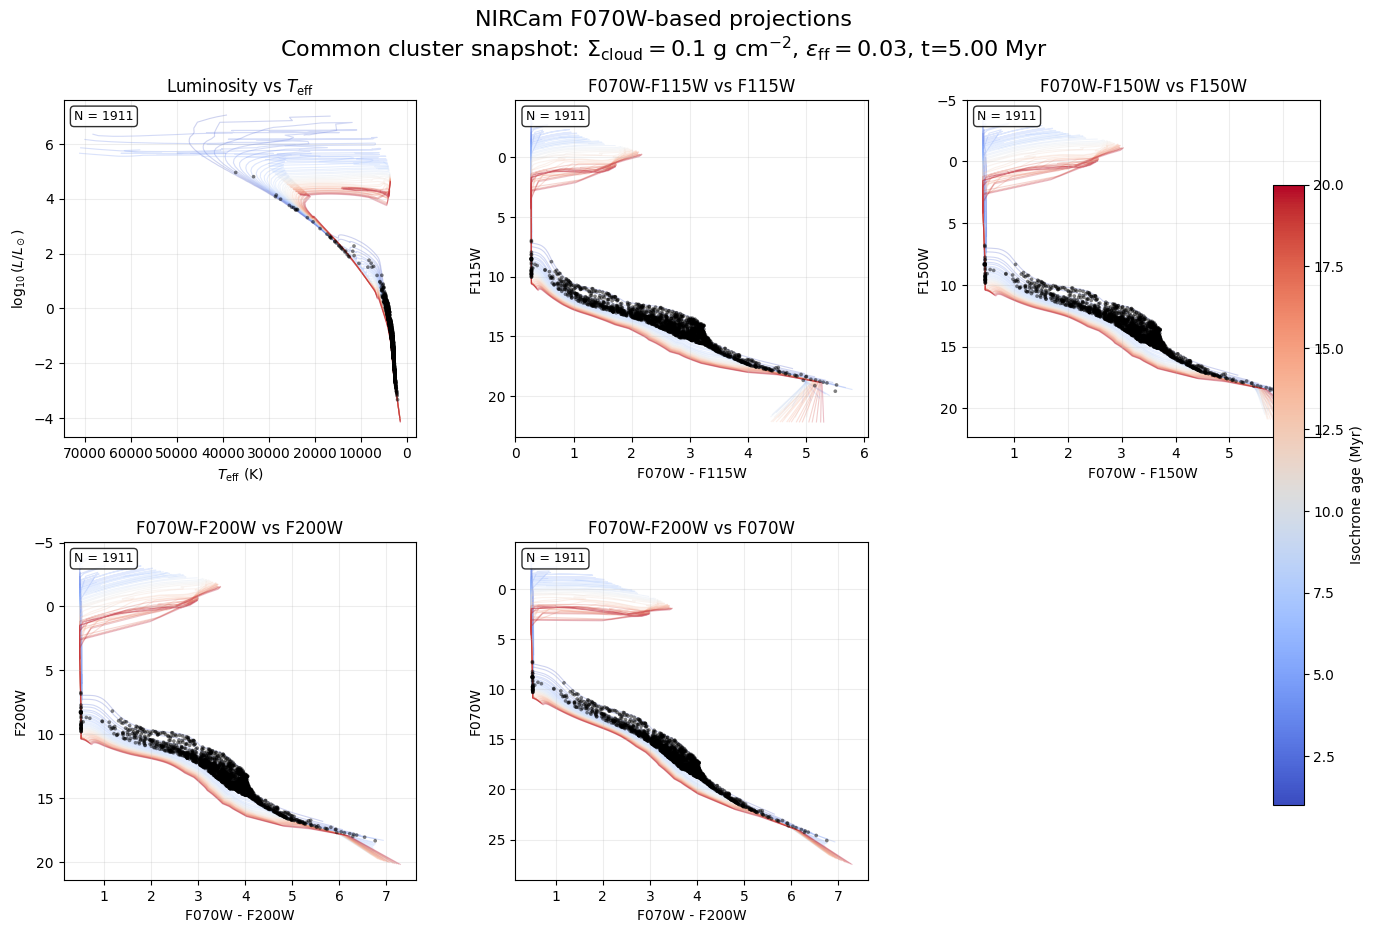

In [20]:
plot_snapshot_group(
    'NIRCam F070W-based projections',
    F070W_GROUP,
    include_hr=True
)

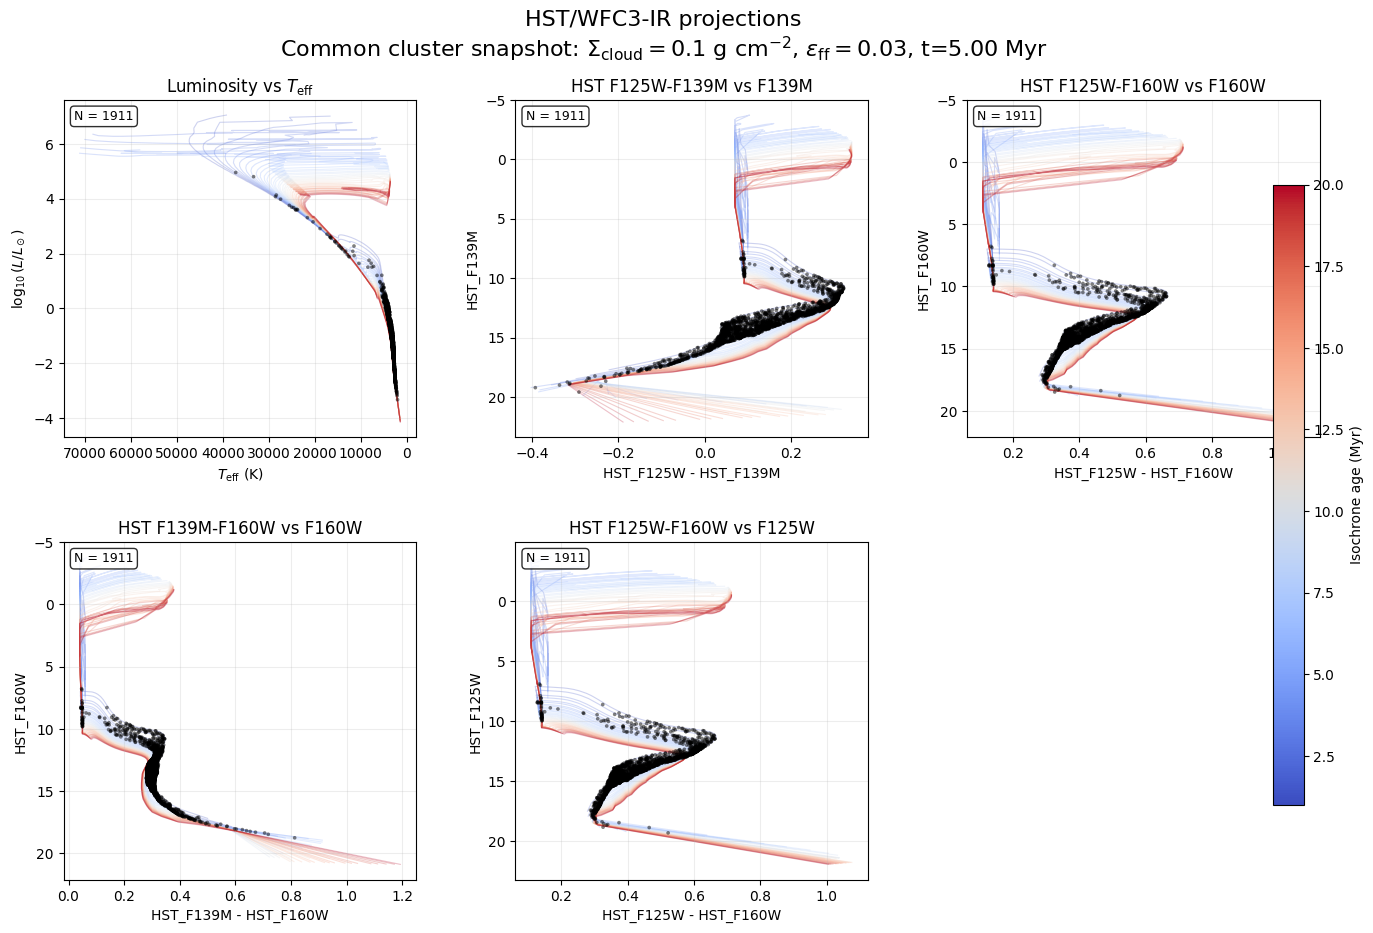

In [21]:
plot_snapshot_group(
    'HST/WFC3-IR projections',
    HST_GROUP,
    include_hr=True
)

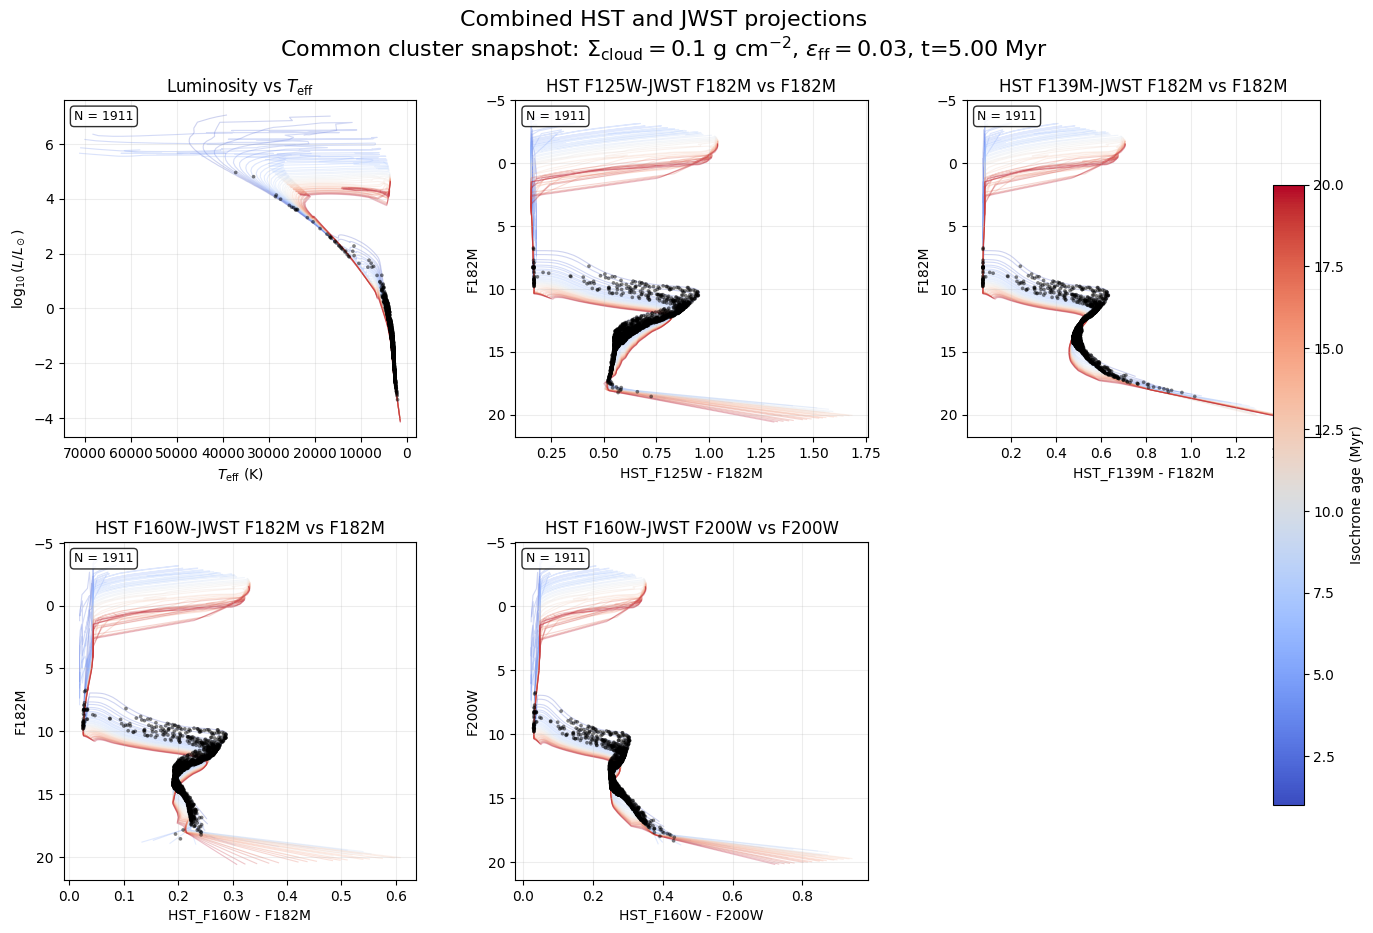

In [22]:
plot_snapshot_group(
    'Combined HST and JWST projections',
    CROSS_INSTRUMENT_GROUP,
    include_hr=True
)

In [23]:
range_rows = []

for group_name, choices in CMD_GROUPS.items():
    for filt_a, filt_b, y_filter, title in choices:
        color = (
            df_snapshot[f'mag_{filt_a}']
            - df_snapshot[f'mag_{filt_b}']
        )

        ymag = df_snapshot[f'mag_{y_filter}']

        range_rows.append({
            'group': group_name,
            'diagram': title,

            'color_min': np.nanmin(color),
            'color_max': np.nanmax(color),
            'color_range': (
                np.nanmax(color)
                - np.nanmin(color)
            ),

            'ymag_min': np.nanmin(ymag),
            'ymag_max': np.nanmax(ymag),
            'ymag_range': (
                np.nanmax(ymag)
                - np.nanmin(ymag)
            ),
        })

df_panel_ranges = pd.DataFrame(range_rows)

display(
    df_panel_ranges.sort_values(
        'color_range',
        ascending=False
    )
)

,group,diagram,color_min,color_max,color_range,ymag_min,ymag_max,ymag_range
2,NIRCam F070W-based projections,F070W-F200W vs F200W,0.498,6.762,6.264,6.745,18.336,11.591
3,NIRCam F070W-based projections,F070W-F200W vs F070W,0.498,6.762,6.264,7.249,25.098,17.849
1,NIRCam F070W-based projections,F070W-F150W vs F150W,0.446,6.176,5.730,6.794,18.922,12.128
0,NIRCam F070W-based projections,F070W-F115W vs F115W,0.273,5.524,5.251,6.975,19.595,12.620
9,Combined HST and JWST projections,HST F139M-JWST F182M vs F182M,0.075,1.017,0.942,6.750,18.563,11.813
8,Combined HST and JWST projections,HST F125W-JWST F182M vs F182M,0.161,0.951,0.790,6.750,18.563,11.813
6,HST/WFC3-IR projections,HST F139M-F160W vs F160W,0.044,0.813,0.769,6.780,18.767,11.987
4,HST/WFC3-IR projections,HST F125W-F139M vs F139M,-0.392,0.322,0.714,6.827,19.580,12.753
5,HST/WFC3-IR projections,HST F125W-F160W vs F160W,0.128,0.663,0.535,6.780,18.767,11.987
7,HST/WFC3-IR projections,HST F125W-F160W vs F125W,0.128,0.663,0.535,6.914,19.289,12.375


In [24]:
LOW_MASS_MIN = 0.01
LOW_MASS_MAX = 1.4


def plot_theoretical_group_low_mass(
    group_name,
    cmd_choices,
    mass_min=LOW_MASS_MIN,
    mass_max=LOW_MASS_MAX
):
    ncols = 2
    nrows = math.ceil(len(cmd_choices) / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(13, 5.2 * nrows),
        squeeze=False
    )

    axes = axes.flatten()

    cmap = plt.get_cmap('coolwarm')
    norm = Normalize(
        vmin=ISO_AGES_MYR.min(),
        vmax=ISO_AGES_MYR.max()
    )

    for ax, cmd_choice in zip(
        axes,
        cmd_choices
    ):
        filt_a, filt_b, y_filter, title = cmd_choice

        for iso, age_myr in zip(
            ISO_GRID,
            ISO_AGES_MYR
        ):
            x, y, mass = get_cmd_coordinates(
                iso,
                cmd_choice
            )

            keep = (
                (mass >= mass_min) &
                (mass <= mass_max)
            )

            if np.sum(keep) == 0:
                continue

            ax.plot(
                x[keep],
                y[keep],
                color=cmap(norm(age_myr)),
                lw=1.0,
                alpha=0.68
            )

        ax.set_title(title)
        ax.set_xlabel(f'{filt_a} - {filt_b}')
        ax.set_ylabel(y_filter)
        ax.invert_yaxis()
        ax.grid(alpha=0.22)

    for ax in axes[len(cmd_choices):]:
        ax.axis('off')

    sm = ScalarMappable(
        norm=norm,
        cmap=cmap
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=axes[:len(cmd_choices)].tolist(),
        pad=0.015,
        fraction=0.025
    )

    cbar.set_label('Isochrone age (Myr)')

    fig.suptitle(
        f'{group_name}: low-mass geometry\n'
        f'{mass_min:.2f}–{mass_max:.2f} $M_\\odot$',
        fontsize=16
    )

    plt.subplots_adjust(
        top=0.90,
        right=0.91,
        wspace=0.28,
        hspace=0.31
    )

    plt.show()

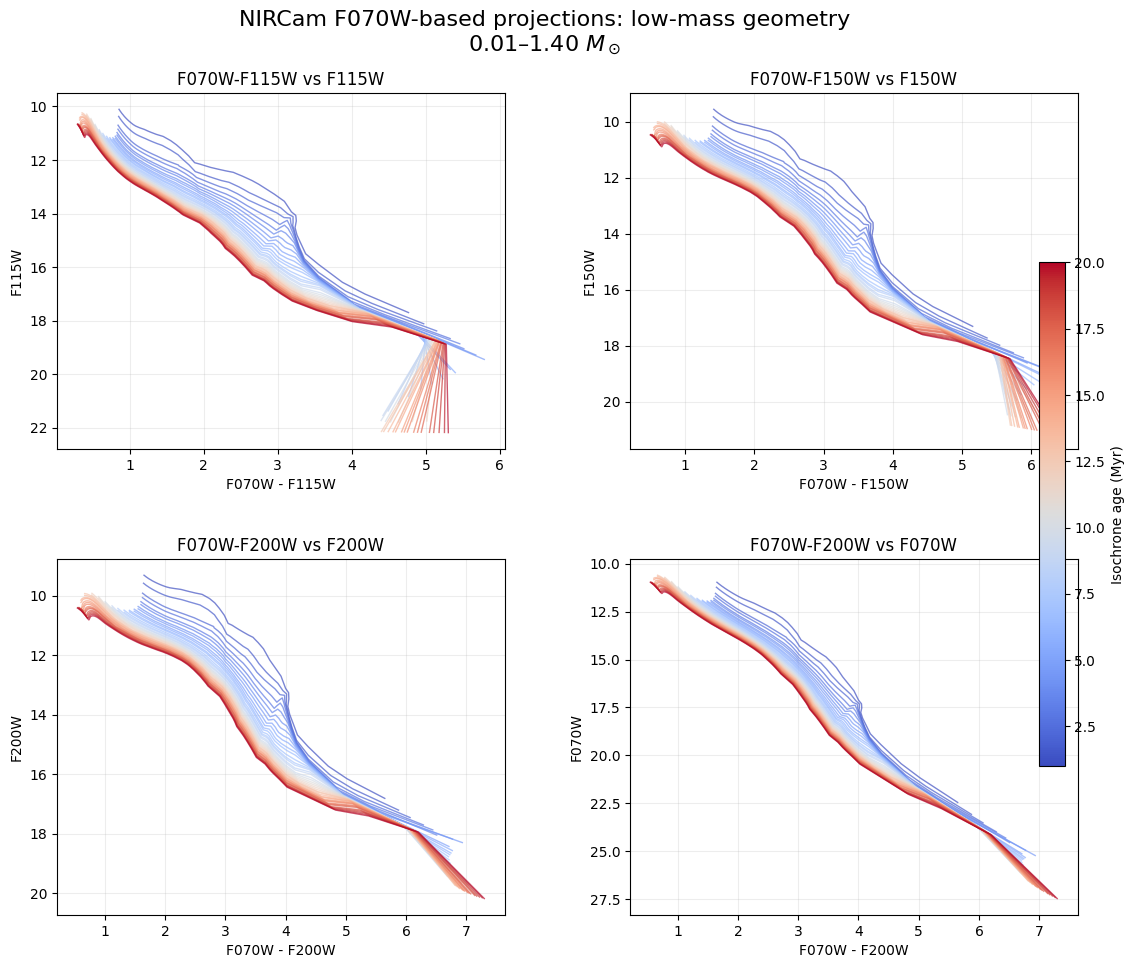

In [25]:
plot_theoretical_group_low_mass(
    'NIRCam F070W-based projections',
    F070W_GROUP
)

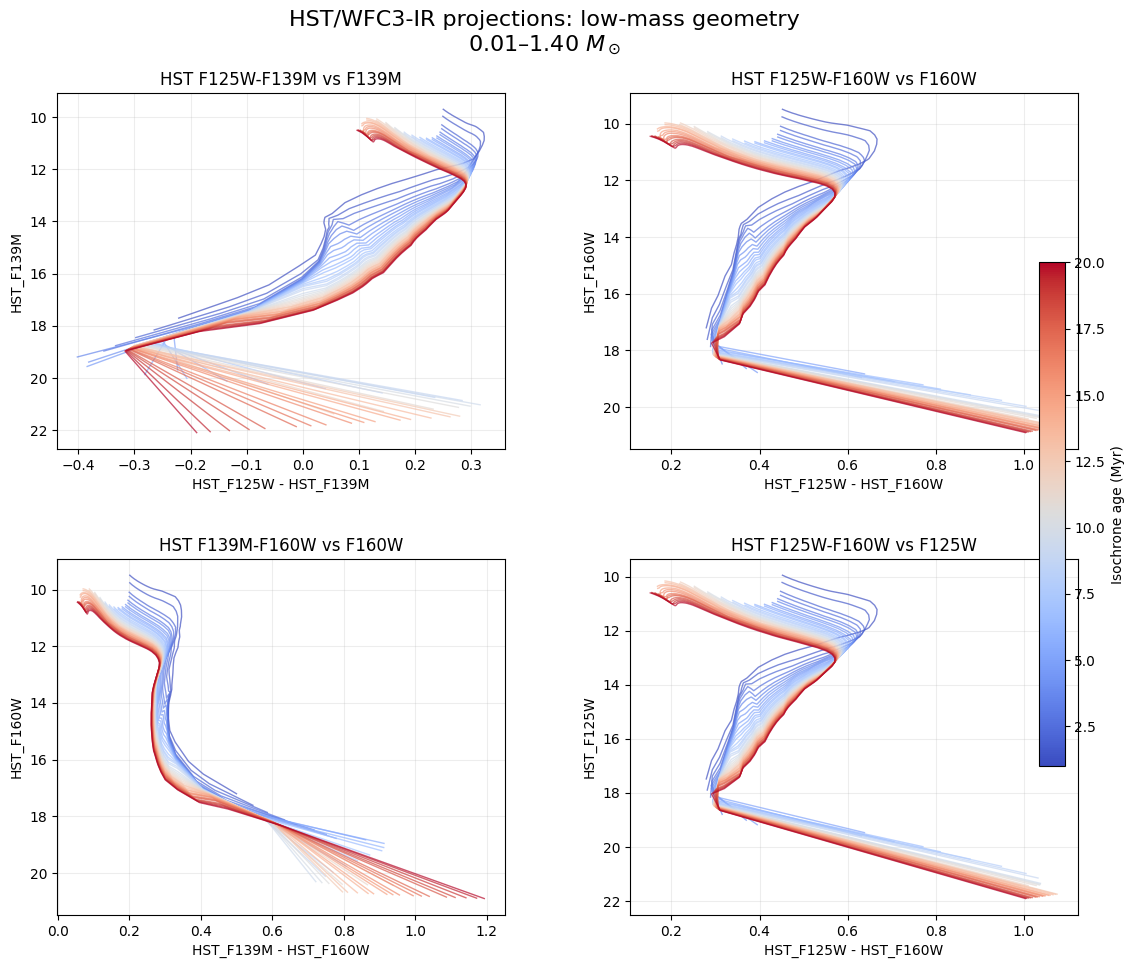

In [26]:
plot_theoretical_group_low_mass(
    'HST/WFC3-IR projections',
    HST_GROUP
)

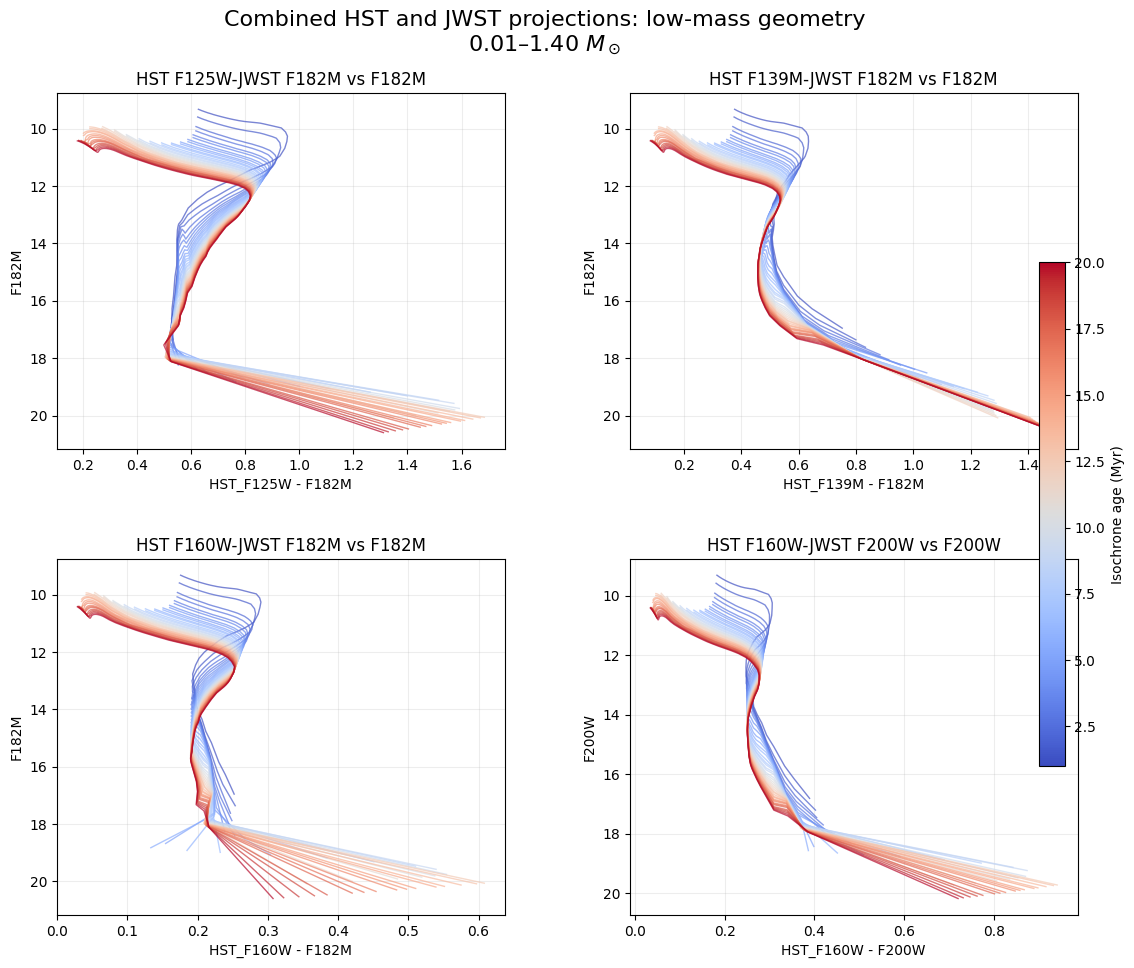

In [27]:
plot_theoretical_group_low_mass(
    'Combined HST and JWST projections',
    CROSS_INSTRUMENT_GROUP
)